# Quantitative Structure-Activity Relationship 
(QSAR) models are computational tools that mathematically associate chemical structure with biological, physical, or toxicological activity, enabling prediction of properties for new compounds. These models play a critical role in drug discovery and chemical risk assessment by predicting effects without costly, time-consuming experiments.

In [57]:
!pip install transformers==4.41.1



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 51.6 MB/s eta 0:00:00:00:0100:01


In [3]:
!pip install optuna

In [4]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [5]:
!pip install selfies

In [58]:
!pip install mordred

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.8/128.8 kB 3.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.7 MB/s eta 0:00:00a 0:00:01
  Created wheel for mordred: filename=mordred-1.2.0-py3-none-any.whl size=176718 sha256=ea961a9cdbf98989d8f7e33471e478a8fc345a516080f4491c41a2d3a52a88b8
  Stored in directory: /root/.cache/pip/wheels/8b/30/0b/84e3f6775306e74cf5957ee4d16b10bf3927dcec44cc23d5f2
Successfully built mordred
  Attempting uninstall: networkx
    Found existing installation: networkx 3.5
    Uninstalling networkx-3.5:
      Successfully uninstalled networkx-3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
nx-cugraph-cu12 25.6.0 requires networkx>=3.2, but you have networkx 2.8

In [6]:
# --- Imports ---
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors, AllChem
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import optuna
from optuna.samplers import TPESampler
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import RDConfig
import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
# now you can import sascore!
import sascorer
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt
from mordred import Calculator, descriptors


In [7]:
import selfies as sf
from transformers import AutoTokenizer, AutoModelForMaskedLM
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F

In [8]:
df = pd.read_csv('/kaggle/input/vegfr-2/bioactivity_handle_VEGFR2.csv')


In [9]:
set(df['standard_type'])

{'IC50'}

In [10]:
df= df[["canonical_smiles", "standard_value",'standard_units']]
df

,canonical_smiles,standard_value,standard_units
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,16500.0,nM
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,20000.0,nM
2,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,7100.0,nM
3,c1ccc(-c2cnc(Nc3ccccn3)o2)cc1,1880.0,nM
4,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,10100.0,nM
...,...,...,...
13805,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,90.0,nM
13806,CN(C)c1ccc2c(Oc3ccc(NC(=O)NCc4ccc(C(F)(F)F)nc4...,9000.0,nM
13807,CN1C(=O)[C@@H](N2CCc3cn(Cc4ccccc4)nc3C2=O)COc2...,1000.0,nM
13808,CN1C(=O)[C@@H](N2CCc3c(nn(Cc4ccccc4)c3Br)C2=O)...,1000.0,nM


In [11]:
df = df[df['standard_value'].notna()].reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13446 entries, 0 to 13445
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   canonical_smiles  13446 non-null  object 
 1   standard_value    13446 non-null  float64
 2   standard_units    13446 non-null  object 
dtypes: float64(1), object(2)
memory usage: 315.3+ KB


In [12]:
len(df[df['standard_units']=='ug.mL-1'])

34

In [13]:
df = df[df['standard_units']=='nM']
df.head()

,canonical_smiles,standard_value,standard_units
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,16500.0,nM
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,20000.0,nM
2,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,7100.0,nM
3,c1ccc(-c2cnc(Nc3ccccn3)o2)cc1,1880.0,nM
4,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,10100.0,nM


In [14]:
set(df['standard_units'])

{'nM'}

In [15]:
bioactivity_threshold = []
for i in df.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [16]:
df = pd.concat([df,pd.Series(bioactivity_threshold,name="bioactivity_threshold")], axis=1)

In [17]:
df["Mol"] = df["canonical_smiles"].apply(lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None)
df = df[df["Mol"].notnull()].reset_index(drop=True)

In [18]:
df.describe()

,standard_value
count,1.341200e+04
mean,7.736929e+03
std,5.190939e+04
min,3.000000e-02
25%,3.200000e+01
50%,2.454700e+02
75%,3.900000e+03
max,4.081000e+06


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [19]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value', axis=1)

    return x

In [20]:
df = pIC50(df)
df

,canonical_smiles,standard_units,bioactivity_threshold,Mol,pIC50
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,nM,inactive,<rdkit.Chem.rdchem.Mol object at 0x780460299d90>,4.782516
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,nM,inactive,<rdkit.Chem.rdchem.Mol object at 0x780460299c40>,4.698970
2,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,nM,intermediate,<rdkit.Chem.rdchem.Mol object at 0x780460299e00>,5.148742
3,c1ccc(-c2cnc(Nc3ccccn3)o2)cc1,nM,intermediate,<rdkit.Chem.rdchem.Mol object at 0x780460299d20>,5.725842
4,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,nM,inactive,<rdkit.Chem.rdchem.Mol object at 0x780460299e70>,4.995679
...,...,...,...,...,...
13407,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,nM,NaN,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f530>,7.045757
13408,CN(C)c1ccc2c(Oc3ccc(NC(=O)NCc4ccc(C(F)(F)F)nc4...,nM,NaN,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f5a0>,5.045757
13409,CN1C(=O)[C@@H](N2CCc3cn(Cc4ccccc4)nc3C2=O)COc2...,nM,NaN,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f610>,6.000000
13410,CN1C(=O)[C@@H](N2CCc3c(nn(Cc4ccccc4)c3Br)C2=O)...,nM,NaN,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f680>,6.000000


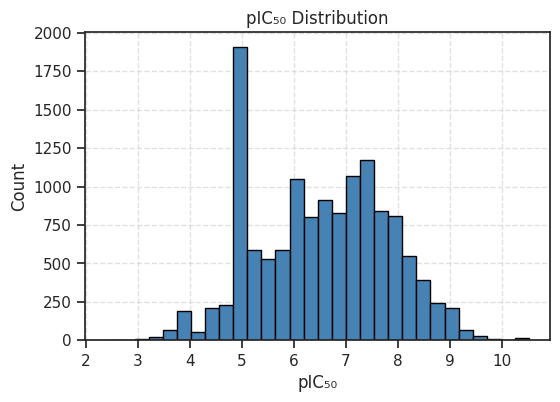

In [21]:
# Ensure column exists
assert 'pIC50' in df.columns, "No 'pIC50' column found in dataset"

# Plot
plt.figure(figsize=(6,4))
plt.hist(df['pIC50'].dropna(), bins=30, color='steelblue', edgecolor='black')
plt.xlabel("pIC₅₀")
plt.ylabel("Count")
plt.title("pIC₅₀ Distribution")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# descriptors for the molecules

## Feature selection

In [22]:
combined_df = pd.read_csv('/kaggle/input/vegfr-2/descriptor_bioactivity_VEGFR2.csv')

In [23]:

from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(combined_df)
df_scaled = pd.DataFrame(df_scaled, columns=combined_df.columns)
df_scaled

,nAcid,nBase,nAromAtom,nAtom,nHeavyAtom,nSpiro,nBridgehead,nHetero,nH,nB,...,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0.0,0.000000,0.447368,0.118943,0.136752,0.0,0.0,0.133333,0.108108,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.000000,0.447368,0.171806,0.196581,0.0,0.0,0.200000,0.153153,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.000000,0.552632,0.154185,0.145299,0.0,0.0,0.066667,0.171171,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.000000,0.447368,0.061674,0.059829,0.0,0.0,0.044444,0.072072,0.0,...,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.111111,0.447368,0.220264,0.230769,0.0,0.0,0.222222,0.216216,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13407,0.0,0.000000,0.473684,0.145374,0.179487,0.0,0.0,0.200000,0.117117,0.0,...,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333
13408,0.0,0.000000,0.578947,0.180617,0.205128,0.0,0.0,0.200000,0.162162,0.0,...,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333
13409,0.0,0.000000,0.447368,0.162996,0.162393,0.0,0.0,0.111111,0.171171,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
13410,0.0,0.000000,0.447368,0.162996,0.170940,0.0,0.0,0.133333,0.162162,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [24]:
variance = df_scaled.var(axis=0)
variance.sort_values(ascending=False, inplace=True)
variance

n10FRing             0.071615
MaxAbsEStateIndex    0.067622
n10FaRing            0.067166
SRW05                0.065773
MinEStateIndex       0.062854
                       ...   
NssNH2               0.000075
Ipc                  0.000075
n10Ring              0.000075
n6FRing              0.000075
NsLi                 0.000000
Length: 566, dtype: float64

In [25]:
print(variance.max())
print(variance.min())
print(variance.mean())

0.07161457832389909
0.0
0.010960404177147656


In [26]:
#get low variance columns
low_variance_columns = variance[variance <= 0.01].index.to_list()
len(low_variance_columns)

332

In [27]:
#Drop low variance columns
selected_desc = combined_df.drop(columns=low_variance_columns, axis=1)
selected_desc

,nAromAtom,nS,nF,nCl,nX,AATS0dv,AATS1dv,AATS6dv,AATS7dv,AATS0d,...,fr_ketone,fr_methoxy,fr_morpholine,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_pyridine,fr_sulfonamd,fr_thiophene,fr_urea
0,17.0,0.0,1.0,1.0,2.0,9.895356,9.558025,6.153846,5.320849,3.880952,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17.0,0.0,1.0,1.0,2.0,10.066758,9.277778,5.790323,5.391904,3.814815,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,21.0,0.0,0.0,0.0,0.0,7.120000,7.518519,3.878049,3.222222,3.520000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17.0,0.0,0.0,0.0,0.0,8.827586,8.935484,4.918919,4.031250,3.551724,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,17.0,0.0,1.0,1.0,2.0,8.886230,8.247987,5.123377,5.101670,3.553846,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13407,18.0,0.0,3.0,1.0,4.0,12.075103,10.362222,5.420550,7.105756,3.750000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
13408,22.0,0.0,3.0,0.0,3.0,11.000000,9.677966,5.201923,4.943396,3.660714,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
13409,17.0,0.0,0.0,0.0,0.0,8.384615,8.089286,4.234848,4.467890,3.615385,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
13410,17.0,0.0,0.0,0.0,1.0,8.520523,8.268519,4.320707,4.645260,3.711538,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
selected_desc.insert(loc=0, column='pIC50', value=df["pIC50"])
selected_desc.insert(loc=0, column='Mol', value=df["Mol"])
selected_desc.insert(loc=0, column='canonical_smiles', value=df["canonical_smiles"])
selected_desc

,canonical_smiles,Mol,pIC50,nAromAtom,nS,nF,nCl,nX,AATS0dv,AATS1dv,...,fr_ketone,fr_methoxy,fr_morpholine,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_pyridine,fr_sulfonamd,fr_thiophene,fr_urea
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,<rdkit.Chem.rdchem.Mol object at 0x780460299d90>,4.782516,17.0,0.0,1.0,1.0,2.0,9.895356,9.558025,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,<rdkit.Chem.rdchem.Mol object at 0x780460299c40>,4.698970,17.0,0.0,1.0,1.0,2.0,10.066758,9.277778,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,<rdkit.Chem.rdchem.Mol object at 0x780460299e00>,5.148742,21.0,0.0,0.0,0.0,0.0,7.120000,7.518519,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,c1ccc(-c2cnc(Nc3ccccn3)o2)cc1,<rdkit.Chem.rdchem.Mol object at 0x780460299d20>,5.725842,17.0,0.0,0.0,0.0,0.0,8.827586,8.935484,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,<rdkit.Chem.rdchem.Mol object at 0x780460299e70>,4.995679,17.0,0.0,1.0,1.0,2.0,8.886230,8.247987,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13407,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f530>,7.045757,18.0,0.0,3.0,1.0,4.0,12.075103,10.362222,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
13408,CN(C)c1ccc2c(Oc3ccc(NC(=O)NCc4ccc(C(F)(F)F)nc4...,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f5a0>,5.045757,22.0,0.0,3.0,0.0,3.0,11.000000,9.677966,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
13409,CN1C(=O)[C@@H](N2CCc3cn(Cc4ccccc4)nc3C2=O)COc2...,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f610>,6.000000,17.0,0.0,0.0,0.0,0.0,8.384615,8.089286,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
13410,CN1C(=O)[C@@H](N2CCc3c(nn(Cc4ccccc4)c3Br)C2=O)...,<rdkit.Chem.rdchem.Mol object at 0x78045fe0f680>,6.000000,17.0,0.0,0.0,0.0,1.0,8.520523,8.268519,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


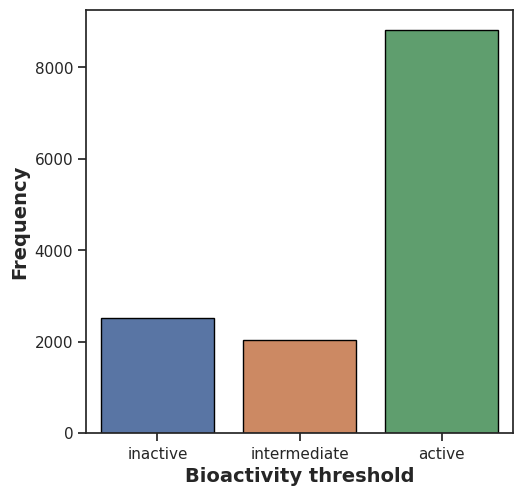

In [29]:
#Frequency plot of the 2 bioactivity_threshold
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_threshold', data=df, edgecolor='black')

plt.xlabel('Bioactivity threshold', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

In [30]:
# Remove rows with NaN values
selected_desc = selected_desc.dropna().reset_index(drop=True)
selected_desc.shape

(13406, 237)

In [31]:
# Compute Morgan Fingerprints (ECFP6) ---
def mol_to_fp(mol, radius=3, n_bits=512):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    
    return np.array(fp)

fps = np.array([mol_to_fp(m) for m in selected_desc["Mol"]])

[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerator
[09:24:37] DEPRECATION WARNING: please use MorganGenerat

In [32]:
from rdkit.Chem import MACCSkeys
def maccs_fp(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

maccs_fp = np.array([maccs_fp(m) for m in selected_desc["Mol"]])

In [33]:
fps.shape,maccs_fp.shape

((13406, 512), (13406, 167))

In [34]:
from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler(feature_range=(0,1))
scaler = preprocessing.StandardScaler()
# scaler = preprocessing.Normalizer()
desc = np.hstack([maccs_fp,selected_desc.drop(columns=["Mol","pIC50","canonical_smiles"]),fps])
X_scaled = scaler.fit_transform(desc)
print(X_scaled.shape)

(13406, 913)


In [35]:
#   Combine descriptors + fingerprints ---

y = selected_desc["pIC50"]
X_scaled.shape, y.shape

((13406, 913), (13406,))

In [36]:
# SMILES -> SELFIES

def SMILES_TO_SELFIES(smi_list):
  SELFIES = []
  for smi in smi_list:
    smi_to_self = sf.encoder(smi)
    # print(smi,'-->',smi_to_self)
    SELFIES.append(smi_to_self)

  return SELFIES
SELFIES = SMILES_TO_SELFIES(selected_desc['canonical_smiles'])
print(len(SELFIES))
print(SELFIES[0])

13406
[C][C][=C][C][Branch1][C][C][=C][Branch2][Ring2][Ring2][/C][=C][\C][=Branch1][C][=O][N][C][=N][C][=N][C][Branch1][S][N][C][=C][C][=C][Branch1][C][F][C][Branch1][C][Cl][=C][Ring1][Branch2][=C][Ring1][#C][Ring2][Ring1][Ring1][NH1][Ring2][Ring1][#Branch2]


# transformers

In [37]:
tokenizer = AutoTokenizer.from_pretrained("cloudrambler/selfiesbert")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [38]:
# Load model directly


base_model =AutoModelForMaskedLM.from_pretrained("cloudrambler/selfiesbert")


config.json:   0%|          | 0.00/658 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/345M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

In [39]:
input_ids = tokenizer(SELFIES,return_tensors="pt",padding=True)
input_ids = input_ids['input_ids']
input_ids.shape

torch.Size([13406, 216])

In [40]:
#  Split data ---
X_train, X_test, y_train, y_test,input_ids_train,input_ids_test = train_test_split(
    X_scaled,
    y,
    input_ids,
    test_size=0.075, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape,input_ids_train.shape,input_ids_test.shape

((12400, 913),
 (1006, 913),
 (12400,),
 (1006,),
 torch.Size([12400, 216]),
 torch.Size([1006, 216]))

In [41]:
class EncodingSELFIES_Dataset(Dataset):

    def __init__(self,tokens,descriptor,y):

        self.tokens = tokens
        self.descriptor = torch.Tensor(descriptor)
        self.y =torch.LongTensor(y.to_list())

    def __getitem__(self,index):
        return self.tokens[index], self.descriptor[index], self.y[index]


    # we can call len(dataset) to return the size
    def __len__(self):
        return len(self.tokens)

In [42]:
# create dataset
train_dataset  = EncodingSELFIES_Dataset(tokens=input_ids_train
                                          ,descriptor=X_train
                                          ,y= y_train
                                          )
train_loader = DataLoader(dataset=train_dataset ,
                          batch_size= 16,
                          shuffle=True)

val_dataset   = EncodingSELFIES_Dataset(tokens=input_ids_test
                                          ,descriptor=X_test
                                          ,y= y_test
                                          )
val_loader = DataLoader(dataset=val_dataset  ,
                          batch_size= 16,
                          shuffle=True)

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import math

class BertQSARRegressor(pl.LightningModule):
    def __init__(self, base_model, feature_len, lr=2e-5):
        super().__init__()
        self.save_hyperparameters()
        self.tokenizer = tokenizer
        self.embed_tokens = base_model.base_model.embeddings
        self.bert_encoder = base_model.base_model.encoder
        self.cnn_encoder = nn.Conv1d(768 + feature_len, 768, kernel_size=3, padding=1)

        self.regressor = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
        self.lr = lr

        # To store predictions for each epoch
        self.train_outputs = []
        self.val_outputs = []

    def forward(self, x, descriptor):
        attention_mask = x.ne(self.tokenizer.pad_token_id).unsqueeze(1).unsqueeze(2).to(torch.bool).to(x.device)
        x = self.embed_tokens(x)
        descriptor = descriptor.unsqueeze(1).repeat(1, x.size(1), 1)
        x = torch.cat((x, descriptor), dim=-1)
        x = x.permute(0, 2, 1)
        x = self.cnn_encoder(x)
        x = x.permute(0, 2, 1)
        x = self.bert_encoder(x, attention_mask=attention_mask)[0]
        cls_token = x[:, 0, :]
        y_hat = self.regressor(cls_token)
        return y_hat.squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, desc, y = batch
        y = y.float()
        y_hat = self(x, desc)
        loss = F.mse_loss(y_hat, y)
        self.train_outputs.append((y_hat.detach().cpu(), y.detach().cpu()))
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, desc, y = batch
        y = y.float()
        y_hat = self(x, desc)
        loss = F.mse_loss(y_hat, y)
        self.val_outputs.append((y_hat.detach().cpu(), y.detach().cpu()))
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        def compute_metrics(outputs):
            y_hat, y = zip(*outputs)
            y_hat = torch.cat(y_hat)
            y = torch.cat(y)
            mse = F.mse_loss(y_hat, y).item()
            rmse = math.sqrt(mse)
            mae = F.l1_loss(y_hat, y).item()
            r2 = 1 - torch.sum((y_hat - y)**2) / torch.sum((y - y.mean())**2)
            return {"r2": r2.item(), "rmse": rmse, "mae": mae}

        if len(self.train_outputs) > 0:
            train_metrics = compute_metrics(self.train_outputs)
            print(f"\n[Train][Epoch {self.current_epoch + 1}] "
                  f"R²={train_metrics['r2']:.4f}, "
                  f"RMSE={train_metrics['rmse']:.4f}, "
                  f"MAE={train_metrics['mae']:.4f}")

        if len(self.val_outputs) > 0:
            val_metrics = compute_metrics(self.val_outputs)
            print(f"[Val][Epoch {self.current_epoch + 1}]   "
                  f"R²={val_metrics['r2']:.4f}, "
                  f"RMSE={val_metrics['rmse']:.4f}, "
                  f"MAE={val_metrics['mae']:.4f}\n")

        # Clear cached outputs
        self.train_outputs.clear()
        self.val_outputs.clear()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)


In [44]:
# 5. Training
# ================================================================
feature_len = X_train.shape[1]
model = BertQSARRegressor(base_model, feature_len
                          # ,lr=0.0002
                         )

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="checkpoints",
    filename="QSAR_VEGFR-2_maccs_fp_{epoch}",
    verbose=True,
    every_n_epochs=1
)

trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=100,
    devices=[0],
    callbacks=[checkpoint_callback]
)

trainer.fit(model, train_loader, val_loader
           # ,ckpt_path=r'/kaggle/working/checkpoints/QSAR_VEGFR-2_epoch=31.ckpt'
           )

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'base_model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['base_model'])`.
2025-10-16 09:25:15.211995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760606715.437572      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760606715.502908      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/core/saving.py:363: Skipping 'base_model' parameter because it is not possible to safely dump to YAML.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:484: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py:527: Found 224 module(s) in eval mode at the start of training. This may lead to unexpec

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]


[Train][Epoch 49] R²=0.7735, RMSE=0.5818, MAE=0.4368
[Val][Epoch 49]   R²=0.6139, RMSE=0.7642, MAE=0.5586



Validation: |          | 0/? [00:00<?, ?it/s]


[Train][Epoch 50] R²=0.7643, RMSE=0.5935, MAE=0.4471
[Val][Epoch 50]   R²=0.6213, RMSE=0.7570, MAE=0.5363

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/trainer.py", line 598, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/trainer.py", line 1011, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/trainer.py", line 1055, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py", line 216, in run
    self.advance()
  File "/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_

TypeError: object of type 'NoneType' has no len()

In [54]:
import torch

checkpoint_path = "checkpoints/QSAR_VEGFR-2_maccs_fp_epoch=49.ckpt"
checkpoint = torch.load(checkpoint_path, weights_only=False)


test_model = model
test_model.load_state_dict(checkpoint["state_dict"])

<All keys matched successfully>

In [55]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
test_model.eval()
test_model.to(device)

BertQSARRegressor(
  (embed_tokens): BertEmbeddings(
    (word_embeddings): Embedding(185, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (bert_encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, 

In [59]:

def calculate_descriptors(smiles_list, reference_df):
    """
    Compute descriptors for a list of SMILES using RDKit and Mordred,
    matching the descriptor columns and order from a reference dataframe.
    """
    # Initialize Mordred calculator (no 3D)
    calc = Calculator(descriptors, ignore_3D=True)
    
    # Prepare molecules
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    
    # Compute Mordred descriptors
    mordred_df = calc.pandas(mols)
    
    # Compute some RDKit descriptors
    rdkit_descs = []
    for mol in mols:
        if mol is None:
            rdkit_descs.append({k: None for k in Descriptors._descList})
            continue
        rdkit_descs.append({name: func(mol) for name, func in Descriptors._descList})
    rdkit_df = pd.DataFrame(rdkit_descs)

    # Merge both descriptor sources
    combined = pd.concat([mordred_df, rdkit_df], axis=1)

    # Align with reference dataframe columns
    # Only keep columns that exist in the reference and fill missing with NaN
    aligned = pd.DataFrame(columns=reference_df.columns)
    for col in reference_df.columns:
        if col in combined.columns:
            aligned[col] = combined[col]
        else:
            aligned[col] = pd.NA

    return aligned


In [60]:
gen_temp1_Smiles = pd.read_csv('vegfr-2/drug_likeness_temp1_VEGFR2_qed_0.5_autoregressive_desirable_desc_epoch_49.csv')['Smiles']
gen_sampling_Smiles = pd.read_csv('vegfr-2/drug_likeness_Stochastic_Sampling_VEGFR2_qed_0.5_autoregressive_desirable_desc_epoch_49.csv')['Smiles']


In [ ]:
desc_gen_temp1=calculate_descriptors(gen_temp1_Smiles, reference_df=selected_desc.drop(columns=["Mol","pIC50","canonical_smiles"]))
desc_gen_sampling=calculate_descriptors(gen_sampling_Smiles, reference_df=selected_desc.drop(columns=["Mol","pIC50","canonical_smiles"]))

desc_gen_temp1.shape,desc_gen_sampling.shape

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [ ]:
assert list(desc_gen_temp1.columns) == list(selected_desc.drop(columns=["Mol","pIC50","canonical_smiles"]).columns)
assert list(desc_gen_sampling.columns) == list(selected_desc.drop(columns=["Mol","pIC50","canonical_smiles"]).columns)

In [ ]:
desc_gen_temp1["Mol"] =gen_temp1_Smiles.apply(lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None)
desc_gen_temp1 = desc_gen_temp1[desc_gen_temp1["Mol"].notnull()].reset_index(drop=True)


desc_gen_sampling["Mol"] = gen_sampling_Smiles.apply(lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None)
desc_gen_sampling = desc_gen_sampling[desc_gen_sampling["Mol"].notnull()].reset_index(drop=True)

In [ ]:
desc_gen_temp1.insert(loc=0, column='Smiles', value=gen_temp1_Smiles)
desc_gen_sampling.insert(loc=0, column='Smiles', value=gen_sampling_Smiles)

In [ ]:
# Remove rows with NaN values
desc_gen_temp1 = desc_gen_temp1.dropna().reset_index(drop=True)
desc_gen_sampling = desc_gen_sampling.dropna().reset_index(drop=True)

desc_gen_temp1.shape , desc_gen_sampling.shape

In [ ]:
fps_gen_temp1 = np.array([mol_to_fp(m) for m in desc_gen_temp1["Mol"]])
fps_gen_sampling = np.array([mol_to_fp(m) for m in desc_gen_sampling["Mol"]])

In [ ]:
maccs_fp_gen_temp1 = np.array([maccs_fp(m) for m in desc_gen_temp1["Mol"]])
maccs_fp_gen_sampling = np.array([maccs_fp(m) for m in desc_gen_sampling["Mol"]])

In [ ]:

X_scaled_gen_temp1 = np.hstack([maccs_fp_gen_temp1,desc_gen_temp1.drop(columns=["Mol","Smiles"]),fps_gen_temp1])
X_scaled_gen_temp1 = scaler.fit_transform(desc_gen_temp1)
print(X_scaled_gen_temp1.shape)


X_scaled_gen_sampling = np.hstack([maccs_fp_gen_sampling,desc_gen_sampling.drop(columns=["Mol","Smiles"]),fps_gen_sampling])
X_scaled_gen_sampling = scaler.fit_transform(X_scaled_gen_sampling)
print(X_scaled_gen_sampling.shape)


In [ ]:
gen_temp1_Selfies =SMILES_TO_SELFIES(desc_gen_temp1['Smiles'])
gen_sampling_Selfies =SMILES_TO_SELFIES(desc_gen_sampling['Smiles'])


input_ids_gen_temp1 = tokenizer(gen_temp1_Selfies,return_tensors="pt",padding=True)
input_ids_gen_temp1 = input_ids_gen_temp1['input_ids']

input_ids_gen_sampling = tokenizer(gen_sampling_Selfies,return_tensors="pt",padding=True)
input_ids_gen_sampling = input_ids_gen_sampling['input_ids']

In [ ]:
class EncodingSELFIES_Dataset(Dataset):

    def __init__(self,tokens,descriptor,smi=None):

        self.tokens = tokens
        self.descriptor = torch.Tensor(descriptor)
        self.smi =smi.to_list()

    def __getitem__(self,index):
        return self.tokens[index], self.descriptor[index]#, self.smi[index]


    # we can call len(dataset) to return the size
    def __len__(self):
        return len(self.tokens)

In [ ]:
# create dataset
gen_temp1_dataset  = EncodingSELFIES_Dataset(tokens=input_ids_gen_temp1
                                          ,descriptor=X_scaled_gen_temp1
                                          # ,smi= desc_gen_temp1['Smiles']
                                          )
gen_temp1_loader = DataLoader(dataset=gen_temp1_dataset ,
                          batch_size= 128,
                          shuffle=False)

gen_sampling_dataset   = EncodingSELFIES_Dataset(tokens=input_ids_gen_sampling
                                          ,descriptor=X_scaled_gen_sampling
                                          # ,smi= desc_gen_sampling['Smiles']
                                          )
gen_sampling_loader = DataLoader(dataset=gen_sampling_dataset  ,
                          batch_size= 128,
                          shuffle=False)

In [ ]:
# 4. --- Predict ---
predictions_gen_sampling = []
model.eval()
with torch.no_grad():
    for x, desc in tqdm(gen_temp1_loader, desc="Predicting"):
        x, desc = x.cuda(), desc.cuda()
        y_hat = test_model(x, desc)
        predictions.extend(y_hat.cpu().numpy().flatten())


In [ ]:
# 4. --- Predict ---
predictions_gen_sampling = []
model.eval()
with torch.no_grad():
    for x, desc in tqdm(gen_sampling_loader, desc="Predicting"):
        x, desc = x.cuda(), desc.cuda()
        y_hat = test_model(x, desc)
        predictions.extend(y_hat.cpu().numpy().flatten())
